# Compare ABC kernel, GMM, and SBI on the same Local Group pair catalogue

This notebook is self-contained: it loads the simulation data, rebuilds the pair catalogue, and compares three inference methods on that catalogue.

The active feature set, target, and analogue-selection settings come from `config/config.json` through `config.loader.load_config()`. Changing the active feature flags or the single active target there changes the experiment for the whole notebook.

The notebook keeps:

- the baseline distribution from all pairs after the selection pipeline $S$
- **ABC kernel**
- **GMM**
- **SBI with normalizing flows**

All three methods are evaluated on the same $(X, \theta, x_{\mathrm{obs}})$ problem.


## 1) Imports and helper modules

This notebook builds the analogue sample in the same way as `generate_analogues.ipynb`, through the `analogues.AnalogueSample` workflow.

The setup below resolves the repo root and TNG outputs path automatically, loads the shared analysis config from `config/config.json`, and then creates:

- `analogue_sample`
- `sub`
- `sample`
- `pair_set`
- `pipeline`
- `halos`

so the comparison cells can run from a fresh kernel without a hardcoded colleague-specific path.


In [53]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = next((path for path in [cwd, *cwd.parents] if (path / "analogues").is_dir()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repo root containing the `analogues` package.")

candidate_paths = [
    repo_root,
    repo_root / "scripts",
    repo_root / "illustris_python",
    Path("/mnt/data"),
]
for pth in candidate_paths:
    if pth.exists() and str(pth) not in sys.path:
        sys.path.insert(0, str(pth))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import illustris_python as il

from analogues import AnalogueSample, FilterConfig, SelectionConfig
from config.loader import load_config
from lg_abc import run_abc_catalog, summarize_posterior
from lg_gmm_kde import (
    prepare_density_problem,
    fit_joint_gmm,
    condition_gmm,
    weighted_gaussian_kde_1d,
)
from lg_sbi import (
    fit_catalog_npe,
    infer_with_npe,
    plot_sbc_rank_hist,
    plot_expected_coverage,
)

print("Repo root:", repo_root)
print("Imports loaded successfully.")


Repo root: /home/tp/Documents/uni/dsp
Imports loaded successfully.


## 2) Load the shared analysis configuration

The main scientific choices now come from `config/config.json`:

- analogue-selection cuts
- pair-filter cuts
- the active observed features
- the single active target to infer

The notebook-local settings below only control method budgets such as the ABC kernel bandwidth, GMM model selection, and SBI training settings.


In [67]:
def resolve_base_path(repo_root: Path) -> str:
    raw_candidates = [
        os.environ.get("TNG_BASE_PATH"),
        os.environ.get("ILLUSTRIS_BASE_PATH"),
        str(repo_root / "tng300" / "outputs"),
    ]

    for raw in raw_candidates:
        if not raw:
            continue
        base = Path(raw).expanduser()
        for candidate in (base, base / "tng300" / "outputs"):
            if (candidate / "groups_099").exists():
                return str(candidate.resolve())

    raise FileNotFoundError(
        "Could not find a valid TNG outputs directory. Set TNG_BASE_PATH or ILLUSTRIS_BASE_PATH "
        "to the outputs directory, or to a root that contains tng300/outputs."
    )


config_loader = load_config()
analysis_config = config_loader.get_config()

FEATURE_INFO = analysis_config.features
ACTIVE_FEATURES = list(FEATURE_INFO.keys())
if not ACTIVE_FEATURES:
    raise ValueError("config/config.json must have at least one active feature.")

TARGET_KEY = analysis_config.target_name
TARGET = analysis_config.target["column"]
TARGET_LOG10 = bool(analysis_config.target.get("log10", False))
TARGET_LABEL = analysis_config.target.get("label", TARGET_KEY)
LOG10_FEATURES = {
    name for name, meta in FEATURE_INFO.items()
    if bool(meta.get("log10", False))
}

# ABC config. The helper also computes a rejection mask internally, so we
# keep a small acceptance fraction even though the notebook reports only
# the kernel-weighted ABC posterior.
ABC_HELPER_ACCEPT_FRAC = 0.05
ABC_KERNEL_BANDWIDTH = 1.0

# GMM config
GMM_COMPONENTS = "bic"  # can also be an integer like 2, 3, 4, ...
GMM_RANDOM_STATE = 0

# SBI config
SBI_CONFIG = {
    "density_model": "nsf",
    "hidden_features": 32,
    "num_transforms": 4,
    "training_batch_size": 256,
    "learning_rate": 5e-4,
    "validation_fraction": 0.1,
    "calibration_fraction": 0.2,
    "stop_after_epochs": 20,
    "max_num_epochs": 300,
    "random_state": 0,
    "show_train_summary": False,
}


def build_x_obs_and_sigma(feature_info, active_features):
    x_obs = np.array([feature_info[name]["obs"] for name in active_features], dtype=float)
    sigma = np.array([feature_info[name]["sigma"] for name in active_features], dtype=float)
    return x_obs, sigma


x_obs, sigma = build_x_obs_and_sigma(FEATURE_INFO, ACTIVE_FEATURES)

BASE_PATH = resolve_base_path(repo_root)
SNAP = 99

ANALOGUE_SELECTION_CONFIG = SelectionConfig(**analysis_config.selection)
ANALOGUE_FILTER_CONFIG = FilterConfig(**analysis_config.filter)

feature_df = pd.DataFrame([
    {
        "feature": name,
        "observed_value": FEATURE_INFO[name]["obs"],
        "sigma": FEATURE_INFO[name]["sigma"],
        "label": FEATURE_INFO[name].get("label", name),
        "description": FEATURE_INFO[name].get("description", ""),
    }
    for name in ACTIVE_FEATURES
])

print("Active feature configuration:")
display(feature_df)
print("Active target:")
display(config_loader.show_active_target())
print("Selection config:")
display(pd.DataFrame([analysis_config.selection]))
print("Filter config:")
display(pd.DataFrame([analysis_config.filter]))

print("TARGET_KEY =", TARGET_KEY)
print("TARGET =", TARGET, "| TARGET_LOG10 =", TARGET_LOG10)
print("TARGET_LABEL =", TARGET_LABEL)
print("x_obs =", x_obs)
print("sigma =", sigma)
print("BASE_PATH =", BASE_PATH)
print("SNAP =", SNAP)


Active feature configuration:


,feature,observed_value,sigma,label,description
0,r_kpc,765.0,11.0,Pair separation $r$ [kpc],Current MW-M31 separation proxy.
1,v_r,-109.3,4.4,Radial velocity $v_r$ [km/s],Relative radial velocity of the pair.
2,v_t,57.0,35.0,Tangential velocity $v_t$ [km/s],Relative tangential velocity of the pair.
3,k_band_small,-23.3,0.1,,
4,k_band_large,-24.0,0.1,,


Active target:


,column,log10,active,label,description
total_virial_mass,log_tot_virial_mass,False,True,Total virial mass,"Total virial mass of the pair,"


Selection config:


,m_stellar_min,m_stellar_max,r_min,r_max,blue_threshold_gr
0,2.000000e+10,5.000000e+11,500.0,1000.0,0.65


Filter config:


,v_tot_min,v_tot_max,vt_min,vt_max,vr_min,vr_max,density_radius,intruder_factor,third_massive_factor
0,0,600,0,300,-400,0,2000,0.5,1.5


TARGET_KEY = total_virial_mass
TARGET = log_tot_virial_mass | TARGET_LOG10 = False
TARGET_LABEL = Total virial mass
x_obs = [ 765.  -109.3   57.   -23.3  -24. ]
sigma = [11.   4.4 35.   0.1  0.1]
BASE_PATH = /home/tp/Documents/uni/dsp/tng300/outputs
SNAP = 99


In [68]:
# Build the analogue sample using the same workflow as generate_analogues.ipynb.
base_path = BASE_PATH
snap = SNAP

analogue_sample = AnalogueSample(
    base_path=base_path,
    selection_config=ANALOGUE_SELECTION_CONFIG,
    filter_config=ANALOGUE_FILTER_CONFIG,
    verbose=True,
    snap=snap,
)

sub = analogue_sample._sub
sample = analogue_sample._sample
pair_set = analogue_sample._pair_set
pipeline = analogue_sample._pipeline
halos = il.groupcat.loadHalos(base_path, snap, fields=["Group_M_Crit200"])
h = analogue_sample._selection_config.hubble_param

display(pd.DataFrame(pipeline.get_cutflow()))

print("Loaded subhalos:", sub["count"])
print("Selected objects:", sample.keep_idx.size)
print("Pairs before filtering:", pair_set.i.size)
print("Pairs after filtering:", pipeline.pairs.i.size)



[DIAGNOSTIC] Simulation Header Constants
╒════════════╤═══════════╤═══════════════╕
│ Parameter  │ Value     │ Units         │
├────────────┼───────────┼───────────────┤
│ Hubble (h) │ 0.6774    │ dimensionless │
├────────────┼───────────┼───────────────┤
│ Box Side   │ 302627.69 │ kpc           │
╘════════════╧═══════════╧═══════════════╛

[DIAGNOSTIC] Sample Selection
╒═════════════════════════════════════════╤══════════╤═════════════════╕
│ Selection Step                          │    Count │ Yield           │
╞═════════════════════════════════════════╪══════════╪═════════════════╡
│ Total Subhalos in Catalog               │ 14485709 │ 100.0%          │
├─────────────────────────────────────────┼──────────┼─────────────────┤
│ Passed Quality Flags (SubhaloFlag==1)   │  1902558 │ 13.1%           │
├─────────────────────────────────────────┼──────────┼─────────────────┤
│ Inside Stellar Mass Window              │    60562 │ 3.2% of good    │
├─────────────────────────────────────────

,label,before,after,frac_kept
0,initial,2655,2655,1.000000
1,No third subhalo more massive than factor x=1....,2655,2601,0.979661
2,No subhalos more massive than factor x=0.5 wit...,2601,2600,0.999616
3,"vt in [0, 300], vr in [-400, 0], v_tot in [0, ...",2600,1761,0.677308


Loaded subhalos: 14485709
Selected objects: 45392
Pairs before filtering: 2655
Pairs after filtering: 1761


## 3) Build the final analogue catalogue and extract the config-selected features and target

This cell adds the convenient FoF-halo `M200c` target columns:

- `m200c_i`, `m200c_j`: parent FoF-halo M200c for the two pair members
- `m200c_big`, `m200c_small`, `m200c_sum`, `m200c_ratio`

These are derived from:

- `SubhaloGrNr` to map each selected subhalo to its parent FoF halo
- `Group_M_Crit200` to get the halo `M200c`

The active feature list and target are then pulled from `config/config.json`.


In [70]:
# Build the final pair catalogue from the analogue sample created above.
pairs = analogue_sample.pairs
pair_i = pairs.i
pair_j = pairs.j

mstar_i = sample.m_stellar[pair_i].astype(np.float64, copy=False)
mstar_j = sample.m_stellar[pair_j].astype(np.float64, copy=False)
mdm_i = sample.m_dark_matter[pair_i].astype(np.float64, copy=False)
mdm_j = sample.m_dark_matter[pair_j].astype(np.float64, copy=False)

k_band_i = sample.k_band[pair_i].astype(np.float64, copy=False)
k_band_j = sample.k_band[pair_j].astype(np.float64, copy=False)

catalog = {
    "r_kpc": pairs.separation.astype(np.float64, copy=False),
    "v_r": pairs.vr.astype(np.float64, copy=False),
    "v_t": pairs.vt.astype(np.float64, copy=False),
    "same_host": pairs.have_same_host.astype(np.float64, copy=False),
    "mstar_i": mstar_i,
    "mstar_j": mstar_j,
    "k_band_small": k_band_i,
    "k_band_large": k_band_j,
    "mstar_big": np.maximum(mstar_i, mstar_j),
    "mstar_small": np.minimum(mstar_i, mstar_j),
    "mdm_i": mdm_i,
    "mdm_j": mdm_j,
    "mdm_sum": mdm_i + mdm_j,
    "log_tot_virial_mass": pairs.log_tot_virial_mass 
}

# Add a few convenient derived columns for target presets.
catalog["mdm_big"] = np.maximum(catalog["mdm_i"], catalog["mdm_j"])
catalog["mdm_small"] = np.minimum(catalog["mdm_i"], catalog["mdm_j"])
catalog["dm_mass_ratio"] = catalog["mdm_big"] / np.clip(catalog["mdm_small"], 1e-30, None)
catalog["mstar_sum"] = catalog["mstar_i"] + catalog["mstar_j"]

selected_group_numbers = np.asarray(sample.grnr, dtype=int)
group_i = selected_group_numbers[pair_i]
group_j = selected_group_numbers[pair_j]

if isinstance(halos, dict):
    group_m200c_native = np.asarray(halos["Group_M_Crit200"], dtype=float)
else:
    group_m200c_native = np.asarray(halos, dtype=float)
group_m200c_msun = group_m200c_native * 1.0e10 / h

m200c_i = group_m200c_msun[group_i]
m200c_j = group_m200c_msun[group_j]

catalog["m200c_i"] = m200c_i
catalog["m200c_j"] = m200c_j
catalog["m200c_big"] = np.maximum(m200c_i, m200c_j)
catalog["m200c_small"] = np.minimum(m200c_i, m200c_j)
catalog["m200c_sum"] = m200c_i + m200c_j
catalog["m200c_ratio"] = catalog["m200c_big"] / np.clip(catalog["m200c_small"], 1e-30, None)

problem = prepare_density_problem(
    catalog=catalog,
    features=ACTIVE_FEATURES,
    target=TARGET,
    log10_features=LOG10_FEATURES,
    target_log10=TARGET_LOG10,
)

X = problem["X"]
theta = problem["theta"]
feature_names = problem["feature_names"]
target_name = TARGET_LABEL

print("Pairs after cuts:", X.shape[0])
print("Number of active features:", X.shape[1])
print("Dropped non-finite rows:", problem["dropped_rows"])
print("Target column:", TARGET)
print("Target label:", target_name)
print("Available convenient target columns:")
print([
    "m200c_big", "m200c_small", "m200c_sum", "m200c_ratio",
    "mdm_sum", "mdm_big", "mdm_small", "dm_mass_ratio", "mstar_sum",
])

same_host_fraction = float(np.mean(group_i == group_j))
print(f"Fraction of same-host pairs in this sample: {same_host_fraction:.3f}")
if TARGET == "m200c_sum" and same_host_fraction > 0:
    print("Warning: m200c_sum double-counts the parent FoF halo for same-host pairs.")

prior_summary = summarize_posterior(theta)
display(pd.DataFrame([prior_summary], index=["all pairs after S"]))


Pairs after cuts: 1761
Number of active features: 5
Dropped non-finite rows: 0
Target column: log_tot_virial_mass
Target label: Total virial mass
Available convenient target columns:
['m200c_big', 'm200c_small', 'm200c_sum', 'm200c_ratio', 'mdm_sum', 'mdm_big', 'mdm_small', 'dm_mass_ratio', 'mstar_sum']
Fraction of same-host pairs in this sample: 0.786


,mean,median,q16,q84
all pairs after S,12.843004,12.775576,12.519577,13.193495


## 4) Sanity plots before inference

These plots answer two basic questions:

1. Is the observed system inside the support of the analogue catalogue?
2. Which features already look common or unusual before conditioning?

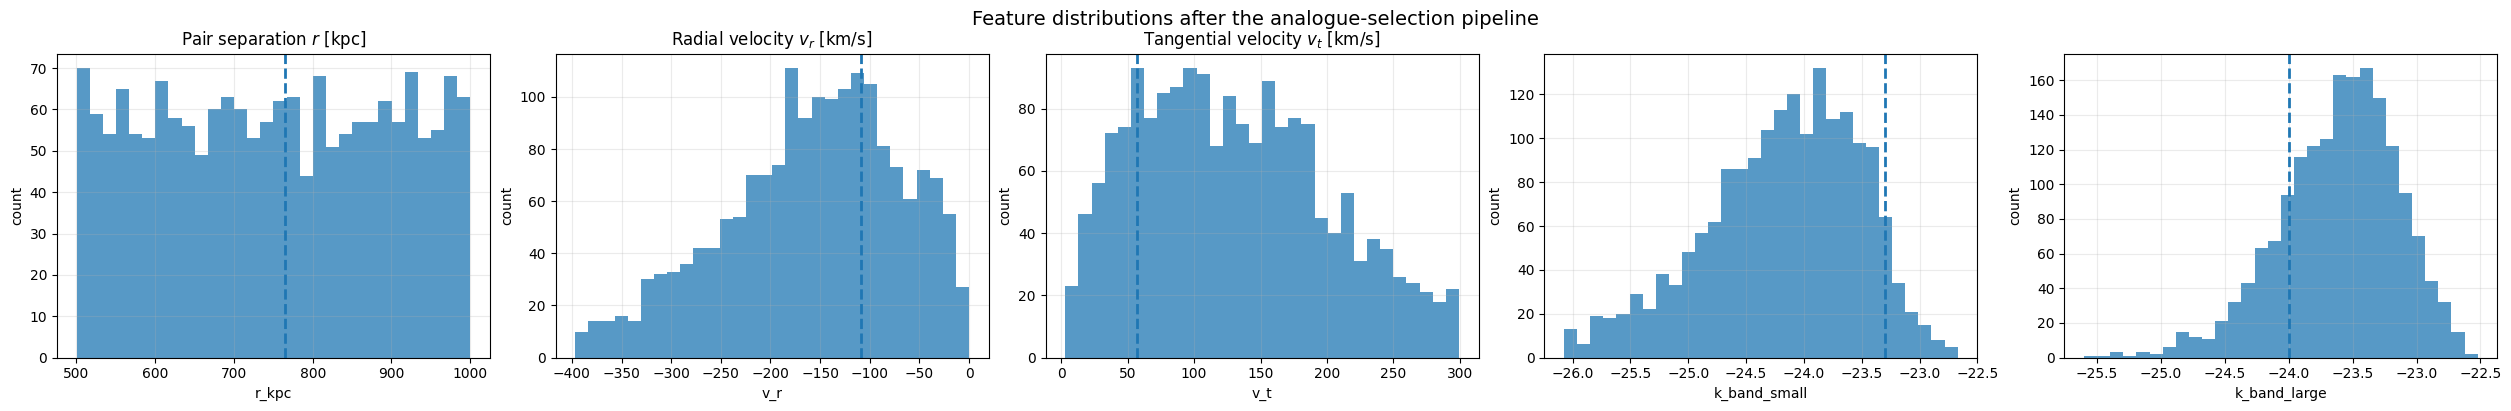

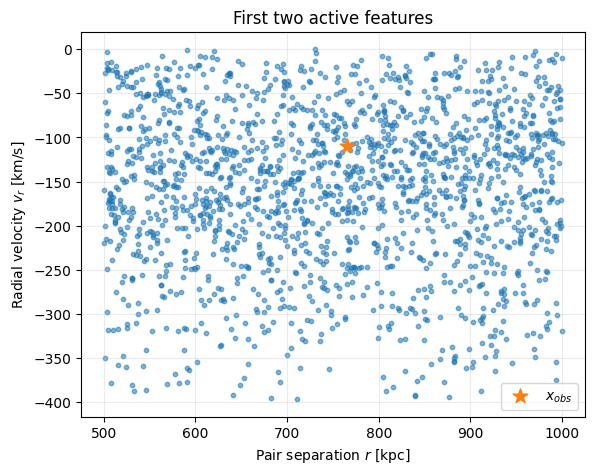

In [71]:
n_features = len(ACTIVE_FEATURES)
fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 3.8), constrained_layout=True)
if n_features == 1:
    axes = [axes]

for j, name in enumerate(ACTIVE_FEATURES):
    ax = axes[j]
    ax.hist(X[:, j], bins=30, alpha=0.75)
    ax.axvline(x_obs[j], linestyle="--", linewidth=2)
    ax.set_title(FEATURE_INFO[name]["label"])
    ax.set_xlabel(name)
    ax.set_ylabel("count")
    ax.grid(alpha=0.25)

fig.suptitle("Feature distributions after the analogue-selection pipeline", y=1.04, fontsize=14)
plt.show()

if len(ACTIVE_FEATURES) >= 2:
    fig, ax = plt.subplots(figsize=(6.5, 5.0))
    ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.55)
    ax.scatter(x_obs[0], x_obs[1], s=120, marker="*", label="$x_{obs}$")
    ax.set_xlabel(FEATURE_INFO[ACTIVE_FEATURES[0]]["label"])
    ax.set_ylabel(FEATURE_INFO[ACTIVE_FEATURES[1]]["label"])
    ax.set_title("First two active features")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.show()

## 5) Run ABC kernel, GMM, and SBI on the same $(X, \theta, x_{\mathrm{obs}})$

A useful way to think about the three kept methods:

- **ABC kernel**: smoothly weight catalogue rows by closeness to $x_{\mathrm{obs}}$
- **GMM**: fit a smooth parametric model to the joint distribution $[\theta, X]$
- **SBI / NPE**: train a neural density estimator for $q_\phi(\theta \mid x)$

All three methods are trained or conditioned on the same analogue catalogue and the same observation vector loaded from the shared config.


In [72]:
# ABC kernel
abc_result = run_abc_catalog(
    X=X,
    theta=theta,
    x_obs=x_obs,
    sigma=sigma,
    accept_frac=ABC_HELPER_ACCEPT_FRAC,
    kernel_bandwidth=ABC_KERNEL_BANDWIDTH,
)

print("ABC kernel summary:")
print(abc_result["summary_kernel"])
print("ABC kernel ESS:", abc_result["ess"])

# GMM
gmm_fit = fit_joint_gmm(
    X=X,
    theta=theta,
    n_components=GMM_COMPONENTS,
    random_state=GMM_RANDOM_STATE,
)
gmm_result = condition_gmm(
    gmm_fit,
    x_obs=x_obs,
    n_samples=20_000,
    random_state=GMM_RANDOM_STATE,
)

print()
print("GMM summary:")
print(gmm_result["summary"])

# SBI
# If needed in a fresh environment, uncomment:
# %pip install sbi

fit = fit_catalog_npe(
    X=X,
    theta=theta,
    x_obs=x_obs,
    feature_names=feature_names,
    target_name=target_name,
    **SBI_CONFIG,
)

sbi_result = infer_with_npe(
    fit,
    x_obs=x_obs,
    num_samples=20_000,
    random_state=SBI_CONFIG["random_state"],
    ppc_draws=500,
    ppc_neighbors=25,
)

print()
print("SBI summary:")
print(sbi_result["summary"])


ABC kernel summary:
{'mean': 12.537091042157941, 'median': 12.602086854112756, 'q16': 12.308119795353303, 'q84': 12.602322825826645, 'ess': 2.1062914180372116}
ABC kernel ESS: 2.1062914180372116

GMM summary:
{'mean': 12.5279626199369, 'median': 12.528609913663855, 'q16': 12.387566407879357, 'q84': 12.668413817509038}
 Neural network successfully converged after 83 epochs.
SBI summary:
{'mean': 12.556990913391113, 'median': 12.5419921875, 'q16': 12.406556930541992, 'q84': 12.691366844177246}


## 6) Build a side-by-side comparison table


In [73]:
def weighted_percentile_of_obs(values, weights, obs):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if values.ndim != 1 or weights.ndim != 1 or values.size != weights.size:
        raise ValueError("values and weights must be matching 1D arrays")
    total = weights.sum()
    if total <= 0:
        return np.nan
    wn = weights / total
    return float(wn[values <= obs].sum())


summary_rows = []

summary_rows.append({
    "method": "all pairs after $S$",
    **prior_summary,
})

summary_rows.append({
    "method": "ABC kernel",
    **abc_result["summary_kernel"],
    "ess": abc_result["ess"],
})

summary_rows.append({
    "method": "GMM",
    **gmm_result["summary"],
})

summary_rows.append({
    "method": "SBI",
    **sbi_result["summary"],
})

summary_df = pd.DataFrame(summary_rows)

if TARGET_LOG10:
    for col in ["median", "q16", "q84"]:
        if col in summary_df.columns:
            summary_df[f"{col}_linear"] = summary_df[col].apply(
                lambda v: np.nan if pd.isna(v) else 10 ** float(v)
            )

display(summary_df)


,method,mean,median,q16,q84,ess
0,all pairs after $S$,12.843004,12.775576,12.519577,13.193495,NaN
1,ABC kernel,12.537091,12.602087,12.308120,12.602323,2.106291
2,GMM,12.527963,12.528610,12.387566,12.668414,NaN
3,SBI,12.556991,12.541992,12.406557,12.691367,NaN


## 7) Compare the posterior over $\theta$


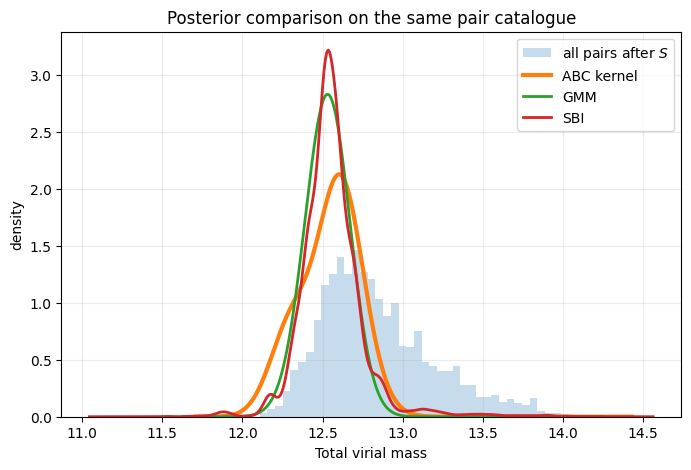

In [74]:
fig, ax = plt.subplots(figsize=(8, 5))

# Prior-like baseline
ax.hist(theta, bins=40, density=True, alpha=0.25, label="all pairs after $S$")

# ABC kernel as a smooth line
grid_abc_kernel, dens_abc_kernel = weighted_gaussian_kde_1d(theta, weights=abc_result["weights"])
ax.plot(grid_abc_kernel, dens_abc_kernel, linewidth=3, label="ABC kernel")

# GMM
ax.plot(gmm_result["theta_grid"], gmm_result["theta_density"], linewidth=2, label="GMM")

# SBI as a smooth line for readability
grid_sbi, dens_sbi = weighted_gaussian_kde_1d(sbi_result["samples"])
ax.plot(grid_sbi, dens_sbi, linewidth=2, label="SBI")

ax.set_xlabel(target_name)
ax.set_ylabel("density")
ax.set_title("Posterior comparison on the same pair catalogue")
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## 8) Feature-space comparison for ABC kernel and SBI

The ABC kernel row reweights the original catalogue rows directly.
The SBI row shows the approximate posterior predictive returned by the wrapped SBI helper.


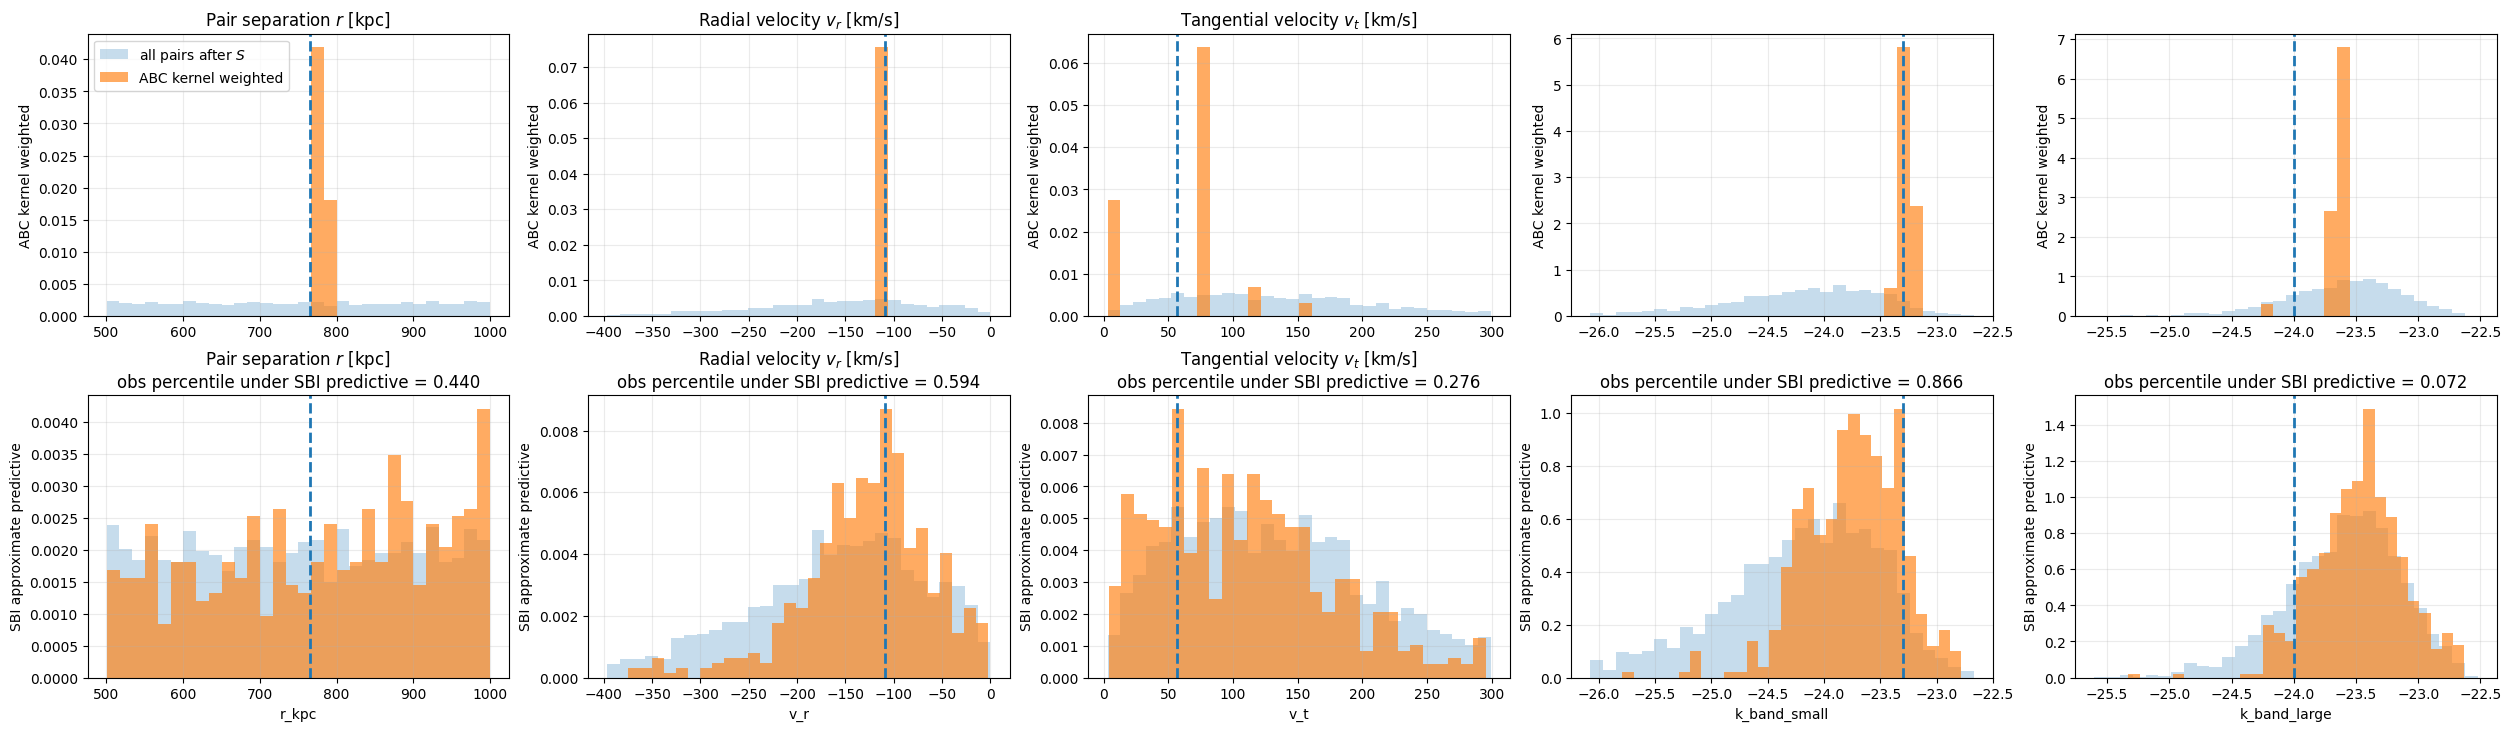

In [61]:
def weighted_hist(ax, values, weights=None, bins=30, alpha=0.5, label=None):
    ax.hist(values, bins=bins, weights=weights, density=True, alpha=alpha, label=label)


x_pred_sbi = sbi_result["x_predictive_samples"]

fig, axes = plt.subplots(
    2,
    len(ACTIVE_FEATURES),
    figsize=(5 * len(ACTIVE_FEATURES), 7.2),
    constrained_layout=True,
)
if len(ACTIVE_FEATURES) == 1:
    axes = np.array(axes).reshape(2, 1)

row_titles = ["ABC kernel weighted", "SBI approximate predictive"]

for j, name in enumerate(ACTIVE_FEATURES):
    base_values = X[:, j]

    # Row 1: ABC kernel weighting
    ax = axes[0, j]
    weighted_hist(ax, base_values, bins=30, alpha=0.25, label="all pairs after $S$")
    weighted_hist(ax, base_values, weights=abc_result["weights"], bins=30, alpha=0.65, label="ABC kernel weighted")
    ax.axvline(x_obs[j], linestyle="--", linewidth=2)
    ax.set_title(FEATURE_INFO[name].get("label", name))
    ax.set_ylabel(row_titles[0])
    ax.grid(alpha=0.25)

    # Row 2: SBI approximate predictive
    ax = axes[1, j]
    weighted_hist(ax, base_values, bins=30, alpha=0.25, label="all pairs after $S$")
    weighted_hist(ax, x_pred_sbi[:, j], bins=30, alpha=0.65, label="SBI predictive")
    ax.axvline(x_obs[j], linestyle="--", linewidth=2)
    pct = sbi_result["x_obs_predictive_percentile"][name]
    ax.set_ylabel(row_titles[1])
    ax.set_xlabel(name)
    ax.set_title(f"{FEATURE_INFO[name].get('label', name)}\nobs percentile under SBI predictive = {pct:.3f}")
    ax.grid(alpha=0.25)

axes[0, 0].legend()
plt.show()


## 9) Support check and interpretation helpers

The support check answers:

- is $x_{\mathrm{obs}}$ inside the range of the training catalogue?
- does the observation have a nearby neighbour in feature space?

This matters most for SBI, because a posterior is much easier to trust when it is not an extrapolation problem.

In [62]:
support = sbi_result["support_check"]

support_df = pd.DataFrame({
    "feature": feature_names,
    "obs": x_obs,
    "feature_min": support["feature_min"],
    "feature_max": support["feature_max"],
    "outside_range": support["outside_range"],
    "nearest_feature_value": support["nearest_x"],
})

display(support_df)

print("n_outside =", support["n_outside"])
print("nearest_distance =", support["nearest_distance"])
print("nearest_index =", support["nearest_index"])

,feature,obs,feature_min,feature_max,outside_range,nearest_feature_value
0,r_kpc,765.0,500.371246,999.991150,False,794.962708
1,v_r,-109.3,-396.569275,-0.097263,False,-145.913544
2,v_t,57.0,3.006503,298.676666,False,54.569374
3,k_band_small,-23.3,-26.073580,-22.670109,False,-23.369749
4,k_band_large,-24.0,-25.337421,-22.522247,False,-23.954889


n_outside = 0
nearest_distance = 0.4849601235687124
nearest_index = 430


## 10) SBI calibration plots

These are practical diagnostics for the neural posterior estimator.

- **SBC rank histogram**: should look roughly uniform if the posterior is calibrated
- **Expected coverage**: empirical coverage should track nominal coverage reasonably well

These checks are not a proof of correctness, but they are much better than trusting the neural posterior blindly.

,train_size,calibration_size,mean_calibration_log_prob
0,1409,352,0.258065


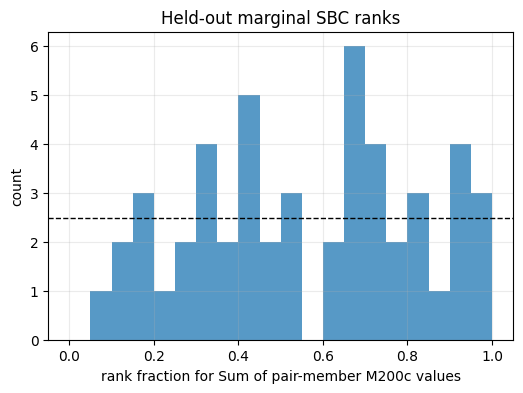

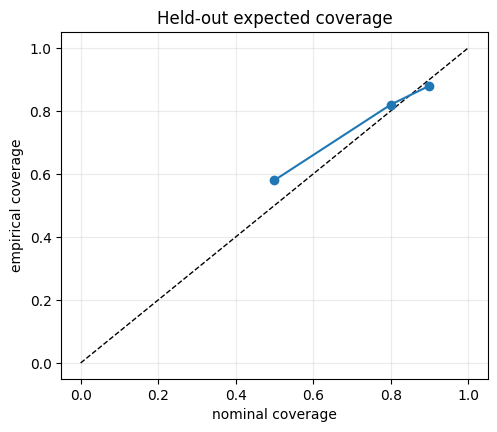

In [63]:
diag = fit["diagnostics"]

display(pd.DataFrame([{
    "train_size": diag["train_size"],
    "calibration_size": diag["calibration_size"],
    "mean_calibration_log_prob": diag["mean_calibration_log_prob"],
}]))

plot_sbc_rank_hist(
    diag["sbc_ranks"],
    num_posterior_samples=200,
    parameter_label=target_name,
    title="Held-out marginal SBC ranks",
)
plt.show()

plot_expected_coverage(
    diag["expected_coverage_1d"],
    title="Held-out expected coverage",
)
plt.show()

## 11) Short text summary generated from the results


In [64]:
def linear_interval_text(summary_dict):
    if not TARGET_LOG10:
        return "linear conversion not requested"
    med = 10 ** float(summary_dict["median"])
    q16 = 10 ** float(summary_dict["q16"])
    q84 = 10 ** float(summary_dict["q84"])
    return f"median = {med:.3e}, q16 = {q16:.3e}, q84 = {q84:.3e}"


print("Prior-like baseline:")
print(prior_summary)
if TARGET_LOG10:
    print(linear_interval_text(prior_summary))
print()

print("ABC kernel:")
print(abc_result["summary_kernel"])
print("ABC kernel ESS:", abc_result["ess"])
if TARGET_LOG10:
    print(linear_interval_text(abc_result["summary_kernel"]))
print()

print("GMM:")
print(gmm_result["summary"])
if TARGET_LOG10:
    print(linear_interval_text(gmm_result["summary"]))
print()

print("SBI:")
print(sbi_result["summary"])
if TARGET_LOG10:
    print(linear_interval_text(sbi_result["summary"]))
print()

print("A quick reading guide:")
print("- The baseline row shows the target distribution before conditioning, after the analogue-selection pipeline S.")
print("- ABC kernel is the nonparametric catalogue-weighted baseline kept in this notebook.")
print("- GMM gives a smooth parametric conditional posterior.")
print("- SBI gives a flexible learned posterior, but its diagnostics matter.")
print("- Active features and the active target come from config/config.json.")


Prior-like baseline:
{'mean': 12.910433755837877, 'median': 12.85594864640199, 'q16': 12.507759200606081, 'q84': 13.31799948867401}
median = 7.177e+12, q16 = 3.219e+12, q84 = 2.080e+13

ABC kernel:
{'mean': 12.449786319419882, 'median': 12.4331200566846, 'q16': 12.432884084970711, 'q84': 12.440545896746118, 'ess': 2.1062914180372116}
ABC kernel ESS: 2.1062914180372116
median = 2.711e+12, q16 = 2.709e+12, q84 = 2.758e+12

GMM:
{'mean': 12.546196191282684, 'median': 12.546326738797042, 'q16': 12.399441904161524, 'q84': 12.68983829901964}
median = 3.518e+12, q16 = 2.509e+12, q84 = 4.896e+12

SBI:
{'mean': 12.559433183765412, 'median': 12.532933235168457, 'q16': 12.414933738708497, 'q84': 12.691762733459473}
median = 3.411e+12, q16 = 2.600e+12, q84 = 4.918e+12

A quick reading guide:
- The baseline row shows the target distribution before conditioning, after the analogue-selection pipeline S.
- ABC kernel is the nonparametric catalogue-weighted baseline kept in this notebook.
- GMM gives a

## 12) Suggested experiments

Once the notebook works end-to-end, the most useful next experiments are:

1. **Toggle the active features in `config/config.json`**
   Make a different subset active, then rerun the notebook from the top.

2. **Switch the active target in `config/config.json`**
   Keep exactly one target preset active at a time.

3. **Adjust the observed values and uncertainties in `config/config.json`**
   This changes the observation vector `x_obs` and the ABC kernel scales `sigma`.

4. **Test smoothness and model choices**
   Vary the ABC kernel bandwidth, GMM component count, and SBI architecture or training budget.

5. **Compare scientific robustness**
   Check whether the median and interval for $\theta$ stay in the same ballpark across baseline, ABC kernel, GMM, and SBI as you change the config.
